<a href="https://colab.research.google.com/github/lafarch/stochastic-process/blob/main/Procesos_Estoc%C3%A1sticos_con_R.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Iniciando con R para Procesos estocásticos

Vamos a crear un vector x y su  vector de sumas acumuladas


In [ ]:
x=1:5
x
y=cumsum(x)
y

[1] 1 2 3 4 5

[1]  1  3  6 10 15

Ahora gráficamos la pareja (x,y)

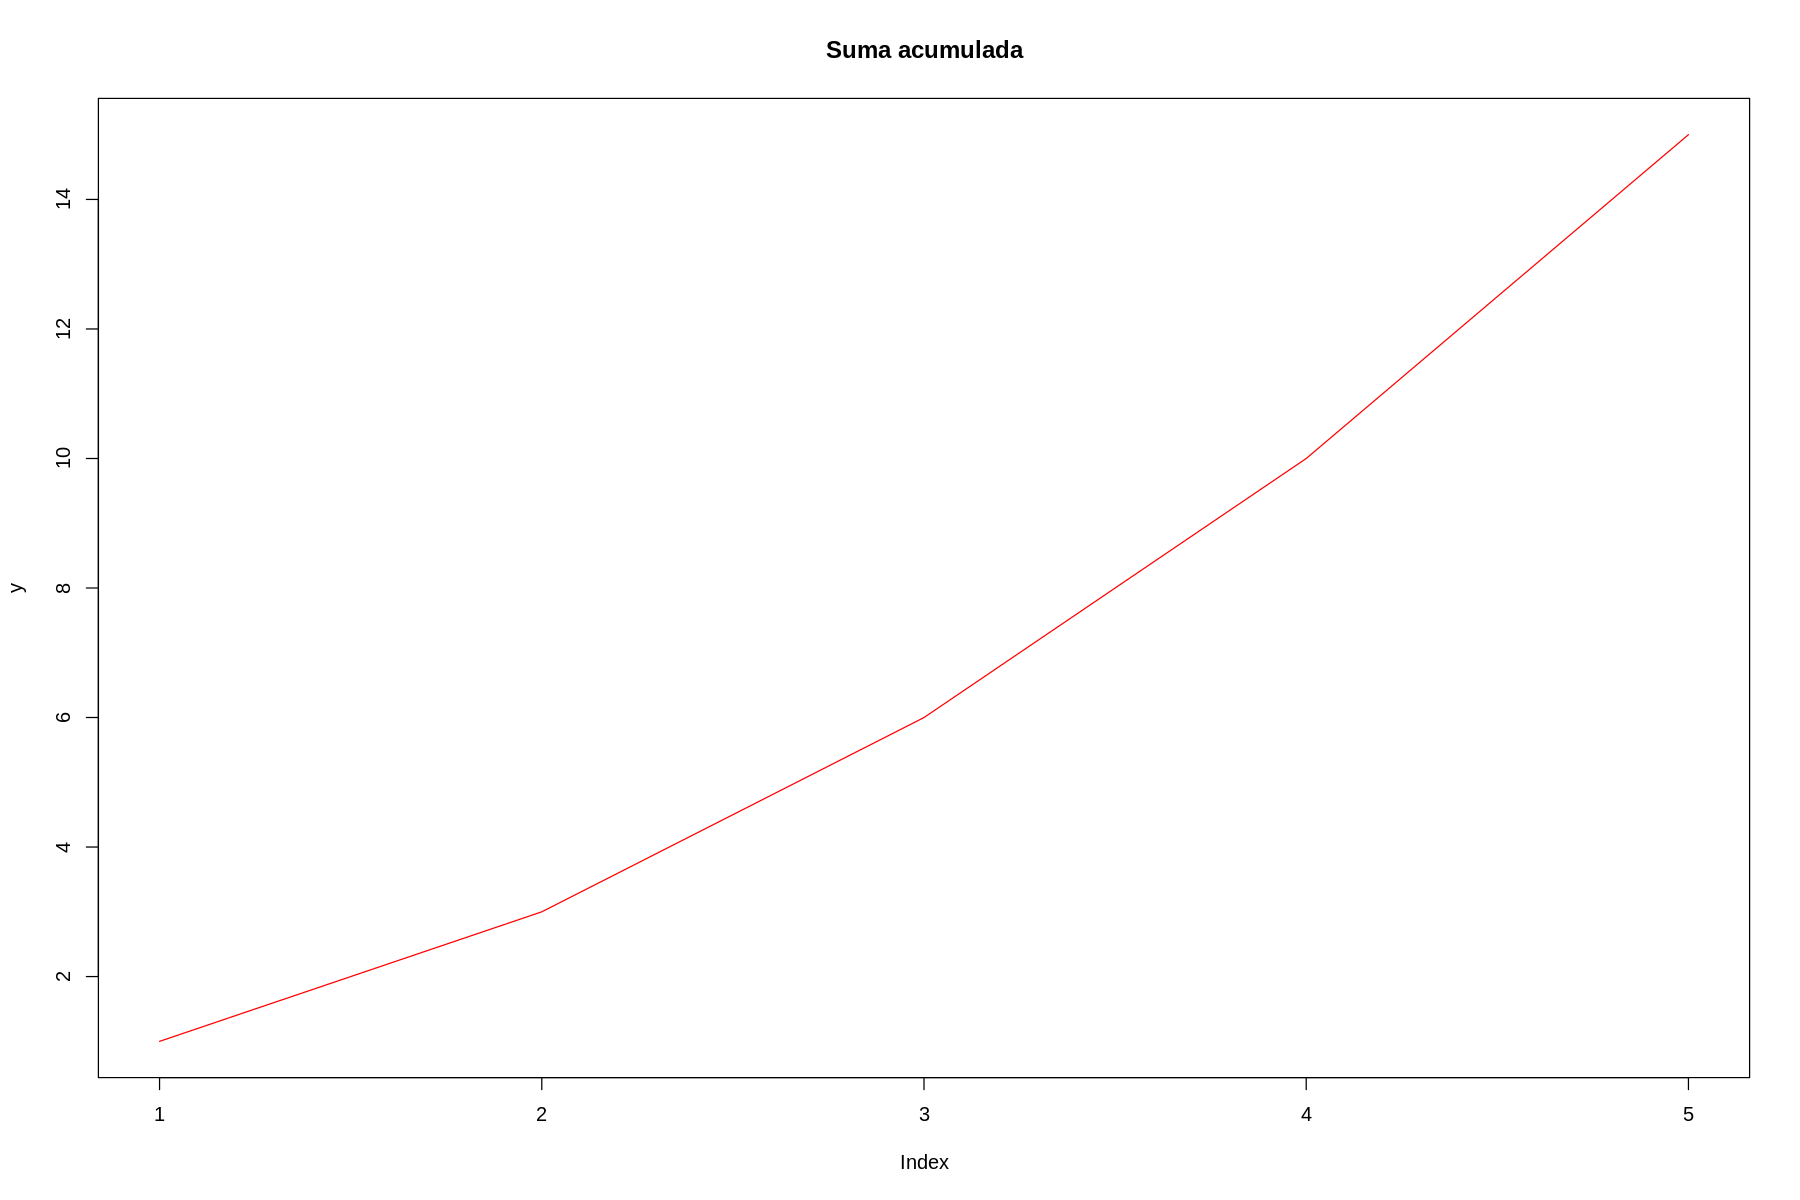

In [ ]:
plot(y,type = "l",col = "red", main = "Suma acumulada")

## La caminata aleatoria

Vamoa contruir una cainata aleatoria
$$S=\sum_{i=1}^nX_i$$
donde cada v.a. $X_i$ toma los valores 1 y -1 ambas con probabilidad de 1/2

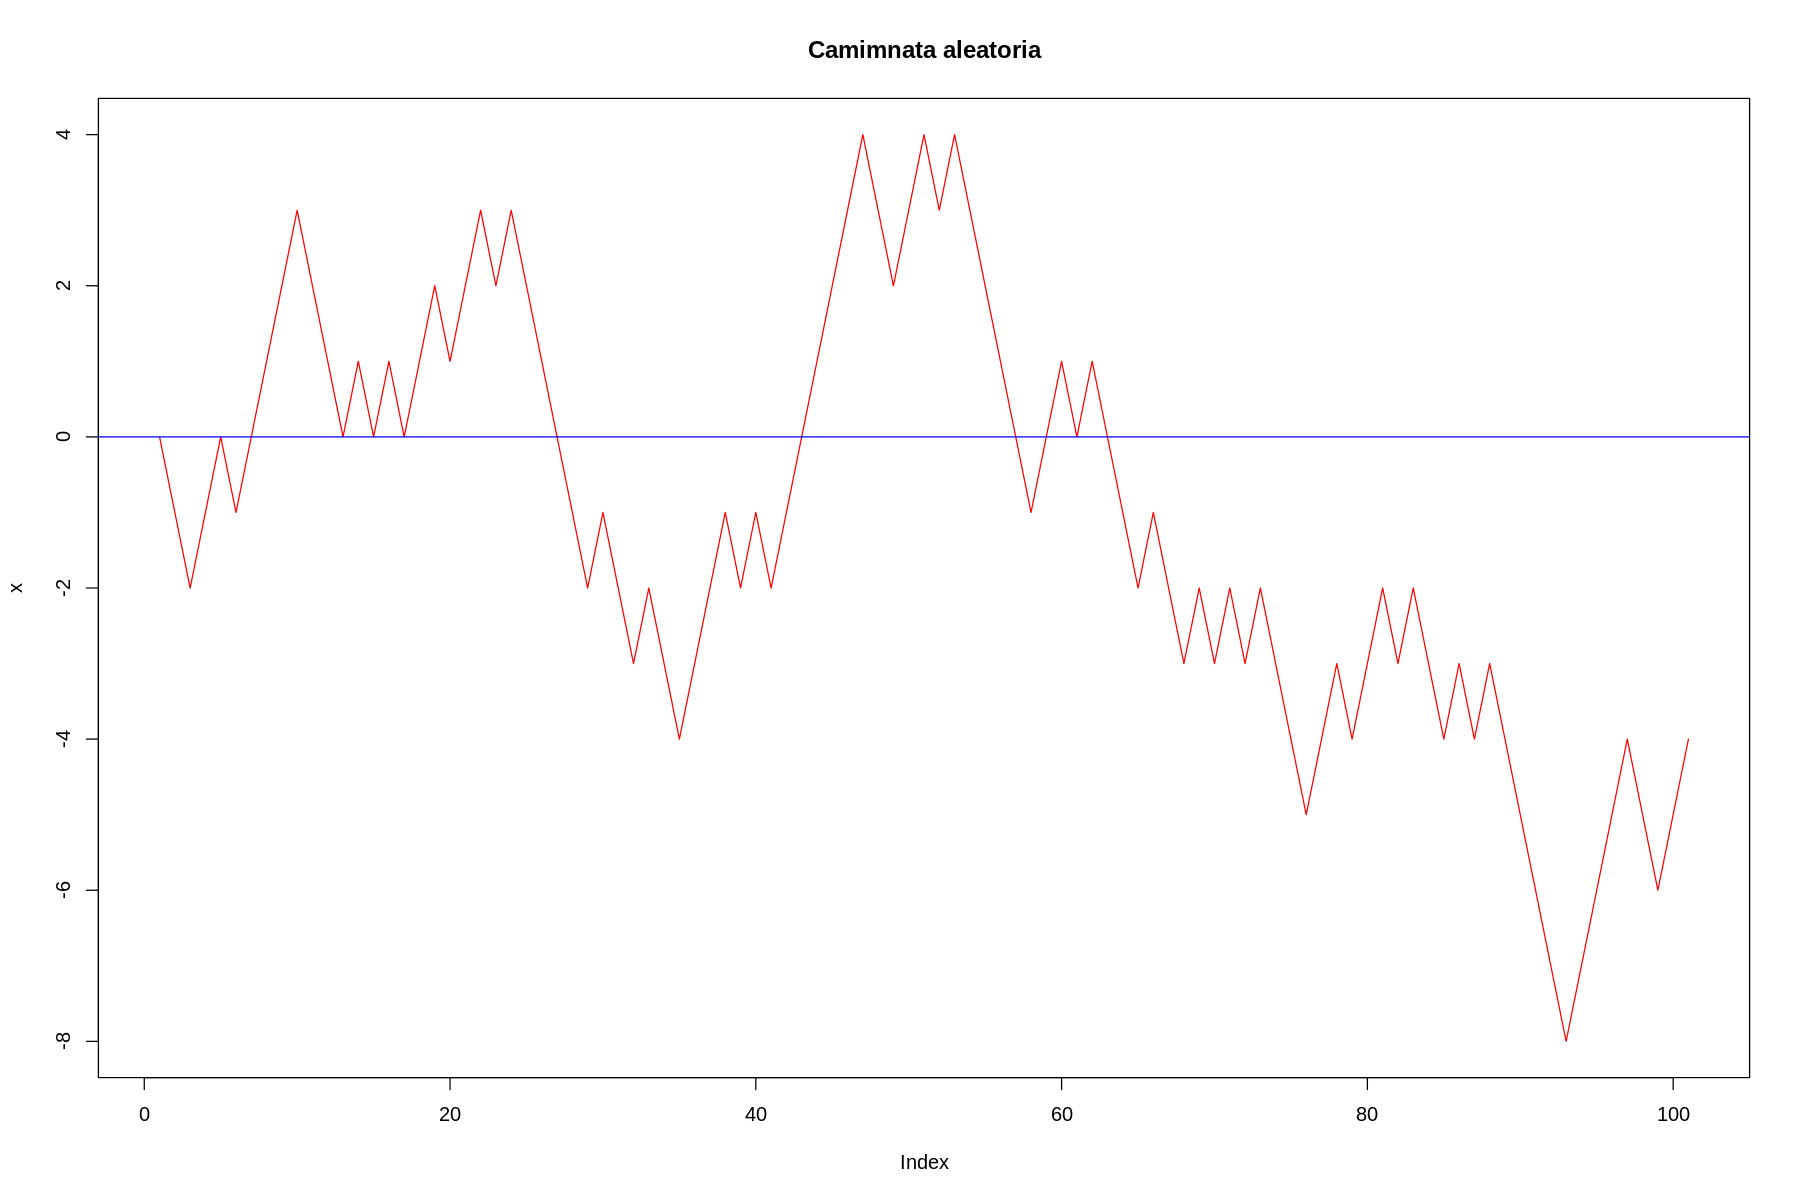

In [ ]:
options(repr.plot.width = 15, repr.plot.height = 10)
set.seed(1); n = 100
x = c(0,cumsum(sample(c(1, -1), n, TRUE, prob = c(0.5,0.5))))
plot(x, type = 'l',col='red',main = 'Camimnata aleatoria')
abline(h=0,col = 'blue')

# Cadenas de Markov usando R
R nos ofrece el paquete markovchain para trabajar con cadenas de Markov. El cual primero cargamos

In [ ]:
install.packages("markovchain")
library(markovchain)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘igraph’, ‘expm’, ‘RcppParallel’, ‘RcppArmadillo’




Supongamos que tenemos una cadena de markov $X=\{X_1,X_2,\ldots\}$ definida en el espacio de estados $S=\{a,b,c\}$ y cuya matriz de transición es:
$$\begin{pmatrix}
0 &0.5 & 0.5\\
0.5 & 0 & 0.5\\
0.5 & 0.5 & 0
\end{pmatrix}$$

Dicha cadena podemos crearla en R de la manera siguiente:

In [ ]:
P=matrix(c(0,0.5,0.5,.5,0,.5,.5,.5,0),nrow = 3,byrow = TRUE)
P

Para construir la matriz de transición creamos el objeto 'markovchain':

In [ ]:
CM1=new("markovchain",transitionMatrix=P,states=c("a","b","c"))
CM1

## Diagrama de transición de la CM
Para visualizar el diagrama de transición de la cadena lo realizamos con la función $plot()$

In [ ]:
plot(CM1,edge.arrow.size=0.2)

## Las características principales de la CM
La función $summary()$ nos da un resumen de las principales características de la cadena de Markov:

In [ ]:
summary(CM1)

## Estados recurrentes, transitivos y absorbentes
Podemos solicitar de manera particular las clases recurrentes con

In [ ]:
recurrentClasses(CM1)

Los estados transitivos

In [ ]:
transientStates(CM1)

Por último los estados absorbentes

In [ ]:
absorbingStates(CM1)

## Análisis probabilístico
Para conocer la probabilidad de transición en 1 paso entre un estado y otro basta con utilizar la función $transitionProbability()$, con los argumentos:

- object: la cadena de markov
- $t0$: el estado en el tiempo 0
- $t1$: el estado en el tiempo 1

La probabilidad de transicion en un paso del estado 'a' al estado 'c' es:

In [ ]:
transitionProbability(object=CM1,t0= 'a', t1= 'c')

El resultado anterior también lo podemos obtener dado que sabemos que eso corresponde a la entrada $P[1,3]$ de la matriz de transición en un paso $P$

In [ ]:
CM1[1,3]

## Matriz de transición en $n$ pasos
Es posible obtener la matriz de transición en n pasos, simplemente computando la n-ésima potencia de la matriz de transición P, como ejemplo calcularemos la matriz de transición en $n = 5$ pasos:

In [ ]:
CM1^5

Así, si buscamos $P_5(a,c)$

In [ ]:
transitionProbability(object=CM1^5,t0= 'a', t1= 'c')

## Distribución de la variable $X_n$
Recordemos que como consecuencia de las ecuaciones de Chapman-Kolmogorov
$$\pi_n=\pi_0P_n=\pi_0 P^n$$
Así, si el vector inicial de la cadena de Markov $CM1$ es
$$\pi_0=(0.5, 0.2, 0.3)$$
entonces $\pi_6$ será:

In [ ]:
pi_0=c(0.5, 0.2, 0.3)
pi_6=pi_0*CM1^6
pi_6

In [ ]:
El vector tiene entrada positivas y además suma $1$:

In [ ]:
sum(pi_6)

## Distribución estacionaria
Recordemos que una distribución es estacionaria si sucede que:
$$\pi^*=\pi^* P$$
La distribución estacionaria la podemos encontrar utilizando la función $steadyStates()$

In [ ]:
DE_CM1=steadyStates(CM1)
DE_CM1

## Ejercicio para entrega

Repite los pasos anteriores con la siguiente matriz de transición en un paso.
\[
P =
\begin{pmatrix}
0.4 & 0.6 & 0   & 0 \\
0.2 & 0.2 & 0.5 & 0.1 \\
0   & 0.2 & 0.8 & 0 \\
0   & 0.5 & 0.5 & 0
\end{pmatrix}
\]


In [ ]:
x=c(0.4,0.6,0,0,0.2,0.2,0.5,0.1,0,0.2,0.8,0,0,0.5,0.5,0)
x
Q=matrix(x,nrow = 4,byrow = T)
Q
A=new("markovchain",transitionMatrix=Q,states=c("0","1","2","3"))

## Ejercicio para entrega
1.  Determine las clases comunicantes, el diagrama de comunicación, los estados cerrados, recurrentes y transitivos y su período de cada uno de ellos.

- $P=\begin{pmatrix}
1 & 0 & 0 & 0\\
0.5 & 0 & 0.5 & 0\\
0 & 0.3 & 0.7 & 0\\
0.2 & 0 & 0.8 & 0
\end{pmatrix}$
- $P=\begin{pmatrix}
0.3 & 0 & 0.7\\
0.4 & 0.6 & 0\\
0.5 & 0 & 0.5
\end{pmatrix}$
-  $P=\begin{pmatrix}
0 & 0.2 & 0 & 0.8\\
0.4 & 0.6 & 0 & 0\\
0 & 0 & 1 & 0\\
0 & 0 & 0.3 & 0.7
\end{pmatrix}$
- $P=\begin{pmatrix}
1/4&1/4&1/4&1/4\\
0& 1/2&1/2&0\\
0&0&0& 1\\
0&0&1&0
\end{pmatrix}$
- $P=\begin{pmatrix}
0&0&0&0&1\\
0&0&1&0&0\\
0&0&0&1/2& 1/2\\
0&0& 1 &0&0\\
1/5&1/5&1/5&1/5&1/5
\end{pmatrix}$








##


2. **Suponga que un mexicano puede estar en $1$ de $4$ estados: Rico, Clase Media, Pobre o en  Pobreza Extrema.  Suponga las siguientes probabilidadades de transición:**


**Supuestos de transición generacional:**

* **Si un mexicano es Rico**, su siguiente generación será:

  * Clase Media: $0.75$
  * Pobre: $0.20$
  * Pobreza Extrema: $0.05$

* **Si un mexicano es de Clase Media**, su siguiente generación será:

  * Rico: $0.05$
  * Clase Media: $0.20$
  * Pobreza Extrema: $0.45$

* **Si un mexicano es Pobre**, su siguiente generación será:

  * Clase Media: $0.40$
  * Pobre: $0.30$
  * Pobreza Extrema: $0.20$

* **Si un mexicano está en Pobreza Extrema**, su siguiente generación será:

  * Clase Media: $0.15$
  * Pobre: $0.03$
  * Pobreza Extrema: $0.55$

---

### Preguntas

1. Determine la **matriz de transición** en un paso.
2. Suponga que un mexicano comienza en la **Clase Media**.
   ¿Cuál será la probabilidad de ser **Rico** después de una, dos y tres generaciones?
3. Suponga que un mexicano comienza en la **Pobreza Extrema**.
   ¿Cuál será la probabilidad de ser **Clase Media** después de una, dos y tres generaciones?
4. ¿Cuál será la **matriz estacionaria** asociada con esta cadena de Markov?

5. Para todo $x = 0, 1, \ldots$, demuestre que existe, y calcule, una **distribución invariante**.

---


